In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Global_Oral.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

Done


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import json
import os

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder("/content/data/train", transform=transform)
val_data   = datasets.ImageFolder("/content/data/valid", transform=transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 176MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
checkpoint_path = "/content/drive/MyDrive/effnet_checkpoint.pth"
history_path = "/content/drive/MyDrive/effnet_history.json"

start_epoch = 0
history = {"loss": [], "accuracy": []}

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    start_epoch = checkpoint['epoch'] + 1

    if os.path.exists(history_path):
        with open(history_path, "r") as f:
            history = json.load(f)

    print(f"Resuming from epoch {start_epoch}")

In [ ]:
num_epochs = 20

for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    history["loss"].append(epoch_loss)
    history["accuracy"].append(epoch_acc)

    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    # SAVE CHECKPOINT
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict()
    }, checkpoint_path)

    # SAVE HISTORY
    with open(history_path, "w") as f:
        json.dump(history, f)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1 | Loss: 0.2731 | Acc: 0.8969
Epoch 2 | Loss: 0.0929 | Acc: 0.9689
Epoch 3 | Loss: 0.0567 | Acc: 0.9800
Epoch 4 | Loss: 0.0345 | Acc: 0.9876
Epoch 5 | Loss: 0.0353 | Acc: 0.9876
Epoch 6 | Loss: 0.0185 | Acc: 0.9946
Epoch 7 | Loss: 0.0143 | Acc: 0.9958
Epoch 8 | Loss: 0.0117 | Acc: 0.9958
Epoch 9 | Loss: 0.0145 | Acc: 0.9958
Epoch 10 | Loss: 0.0111 | Acc: 0.9964
Epoch 11 | Loss: 0.0109 | Acc: 0.9982
Epoch 12 | Loss: 0.0161 | Acc: 0.9952
Epoch 13 | Loss: 0.0079 | Acc: 0.9985
Epoch 14 | Loss: 0.0086 | Acc: 0.9967
Epoch 15 | Loss: 0.0131 | Acc: 0.9970
Epoch 16 | Loss: 0.0086 | Acc: 0.9967
Epoch 17 | Loss: 0.0048 | Acc: 0.9985
Epoch 18 | Loss: 0.0368 | Acc: 0.9946
Epoch 19 | Loss: 0.0210 | Acc: 0.9927
Epoch 20 | Loss: 0.0185 | Acc: 0.9964


In [ ]:
import torch
import json

checkpoint = torch.load("/content/drive/MyDrive/effnet_checkpoint.pth")
model.load_state_dict(checkpoint['model'])
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in DataLoader(
        datasets.ImageFolder("/content/data/test", transform=transform),
        batch_size=16, shuffle=False):

        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

cm = confusion_matrix(all_labels, all_preds)

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall/Sensitivity: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9807
Precision: 0.9854
Recall/Sensitivity: 0.9758
Specificity: 0.9855
F1 Score: 0.9806


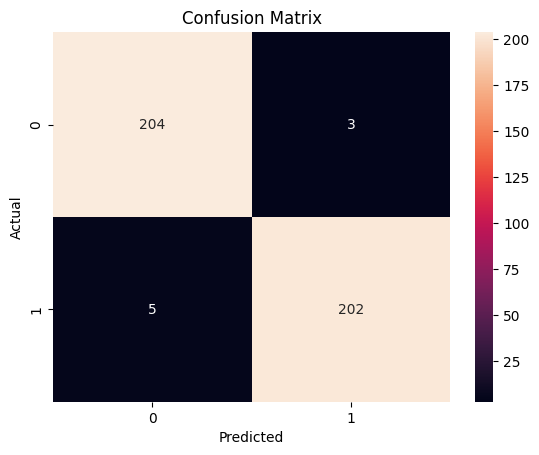

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("/content/drive/MyDrive/confusion_matrix.png")
plt.show()

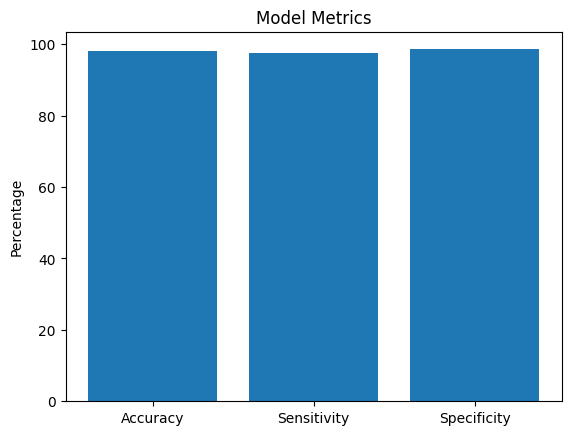

In [ ]:
metrics = {
    "Accuracy": acc*100,
    "Sensitivity": sensitivity*100,
    "Specificity": specificity*100
}

plt.figure()
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Percentage")
plt.title("Model Metrics")
plt.savefig("/content/drive/MyDrive/metrics_bar.png")
plt.show()

In [ ]:
with open("/content/drive/MyDrive/effnet_history.json", "r") as f:
    history = json.load(f)

loss = history["loss"]
acc_hist = [x*100 for x in history["accuracy"]]
epochs = range(1, len(loss)+1)

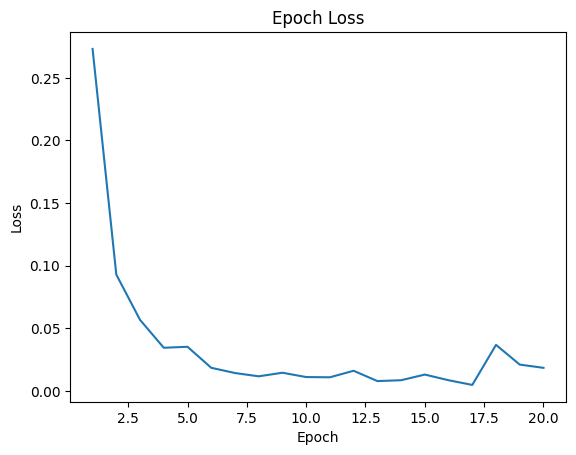

In [ ]:
plt.figure()
plt.plot(epochs, loss)
plt.title("Epoch Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("/content/drive/MyDrive/loss_graph.png")
plt.show()

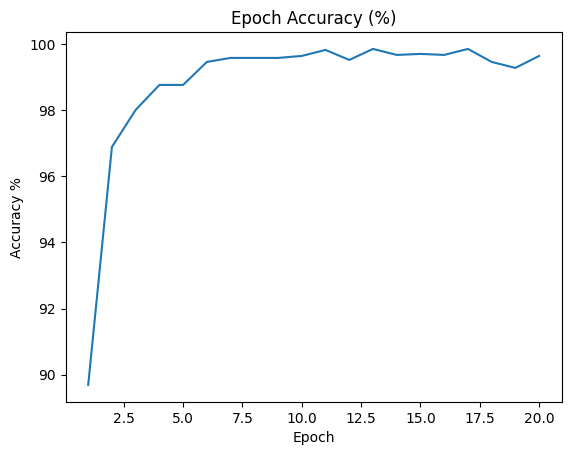

In [ ]:
plt.figure()
plt.plot(epochs, acc_hist)
plt.title("Epoch Accuracy (%)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.savefig("/content/drive/MyDrive/accuracy_graph.png")
plt.show()

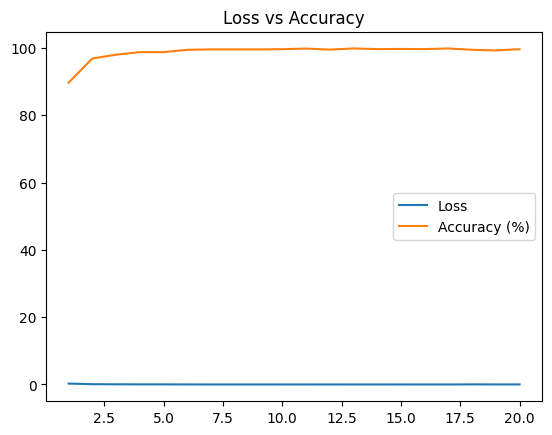

In [ ]:
plt.figure()
plt.plot(epochs, loss, label="Loss")
plt.plot(epochs, acc_hist, label="Accuracy (%)")
plt.legend()
plt.title("Loss vs Accuracy")
plt.savefig("/content/drive/MyDrive/loss_acc_combined.png")
plt.show()

In [ ]:
import os, json, torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

SAVE_DIR = "/content/drive/MyDrive/EfficientNet_Final/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------- 1. SAVE FINAL MODEL ----------
torch.save({
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict()
}, SAVE_DIR + "final_model.pth")

# ---------- 2. LOAD HISTORY ----------
with open("/content/drive/MyDrive/effnet_history.json", "r") as f:
    history = json.load(f)

# ---------- 3. TEST LOADER ----------
from torchvision import datasets
from torch.utils.data import DataLoader

test_data = datasets.ImageFolder("/content/data/test", transform=transform)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

# ---------- 4. GET PREDICTIONS ----------
def get_preds(loader):
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_preds(test_loader)

# ---------- 5. METRICS ----------
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)

metrics = {
    "accuracy": acc,
    "precision": precision,
    "recall (sensitivity)": recall,
    "specificity": specificity,
    "f1_score": f1
}

# SAVE METRICS JSON
with open(SAVE_DIR + "final_metrics.json", "w") as f:
    json.dump(metrics, f)

print(metrics)

# ---------- 6. CONFUSION MATRIX IMAGE ----------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.savefig(SAVE_DIR + "confusion_matrix.png")
plt.close()

# ---------- 7. BAR GRAPH (IN %) ----------
plt.figure()
plt.bar(
    ["Accuracy","Sensitivity","Specificity"],
    [acc*100, recall*100, specificity*100]
)
plt.ylabel("Percentage")
plt.title("Metrics (%)")
plt.savefig(SAVE_DIR + "metrics_bar.png")
plt.close()

# ---------- 8. TRAINING GRAPHS ----------
loss = history["loss"]
accuracy = [x*100 for x in history["accuracy"]]

# Loss graph
plt.figure()
plt.plot(loss)
plt.title("Epoch Loss")
plt.savefig(SAVE_DIR + "loss.png")
plt.close()

# Accuracy graph (%)
plt.figure()
plt.plot(accuracy)
plt.title("Epoch Accuracy (%)")
plt.savefig(SAVE_DIR + "accuracy.png")
plt.close()

# Combined graph
plt.figure()
plt.plot(loss, label="Loss")
plt.plot(accuracy, label="Accuracy (%)")
plt.legend()
plt.title("Loss vs Accuracy")
plt.savefig(SAVE_DIR + "combined.png")
plt.close()

# ---------- 9. SAVE PREDICTIONS ----------
np.save(SAVE_DIR + "y_true.npy", y_true)
np.save(SAVE_DIR + "y_pred.npy", y_pred)

print("🔥 EVERYTHING SAVED SUCCESSFULLY")

{'accuracy': 0.9806763285024155, 'precision': 0.9853658536585366, 'recall (sensitivity)': 0.9758454106280193, 'specificity': np.float64(0.9855072463768116), 'f1_score': 0.9805825242718447}
🔥 EVERYTHING SAVED SUCCESSFULLY


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
model = load_model('/content/Global_EfficientNet.h5')   # change path if needed
print("Model loaded")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/Global_EfficientNet.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import os
os.listdir('/content')

['.config', 'drive', 'sample_data']

In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Global_Oral.zip',
 'effnet_history.json',
 'effnet_checkpoint.pth',
 'confusion_matrix.png',
 'metrics_bar.png',
 'loss_graph.png',
 'accuracy_graph.png',
 'loss_acc_combined.png',
 'EfficientNet_Final']

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# New syntax
model = models.efficientnet_b0(weights=None)

# Binary classification
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

# Load checkpoint
path = '/content/drive/MyDrive/effnet_checkpoint.pth'
checkpoint = torch.load(path, map_location='cpu')

# See keys inside checkpoint
print(checkpoint.keys())

# Load only model weights
model.load_state_dict(checkpoint['model'])

model.eval()
print("Model loaded successfully")

dict_keys(['epoch', 'model', 'optimizer'])
Model loaded successfully


In [ ]:
import json
import matplotlib.pyplot as plt

with open('/content/drive/MyDrive/effnet_history.json', 'r') as f:
    history = json.load(f)

print(history.keys())

dict_keys(['loss', 'accuracy'])


In [ ]:
print(history.keys())

dict_keys(['loss', 'accuracy'])


In [ ]:
import matplotlib.pyplot as plt

print("Available Keys:", history.keys())

# Try to detect keys automatically
acc_key = None
f1_key = None
loss_key = None

for k in history.keys():
    lk = k.lower()
    if 'acc' in lk and ('val' in lk or 'valid' in lk):
        acc_key = k
    if 'f1' in lk and ('val' in lk or 'valid' in lk):
        f1_key = k
    if 'loss' in lk and ('val' in lk or 'valid' in lk):
        loss_key = k

print("Accuracy Key:", acc_key)
print("F1 Key:", f1_key)
print("Loss Key:", loss_key)

epochs = range(1, len(history[acc_key]) + 1)

plt.figure(figsize=(12,6))

if acc_key:
    plt.plot(epochs, history[acc_key], marker='o', label='Validation Accuracy')

if f1_key:
    plt.plot(epochs, history[f1_key], marker='s', linestyle='--', label='Validation F1 Score')

plt.title("Validation Performance per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Performance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Available Keys: dict_keys(['loss', 'accuracy'])
Accuracy Key: None
F1 Key: None
Loss Key: None


KeyError: None

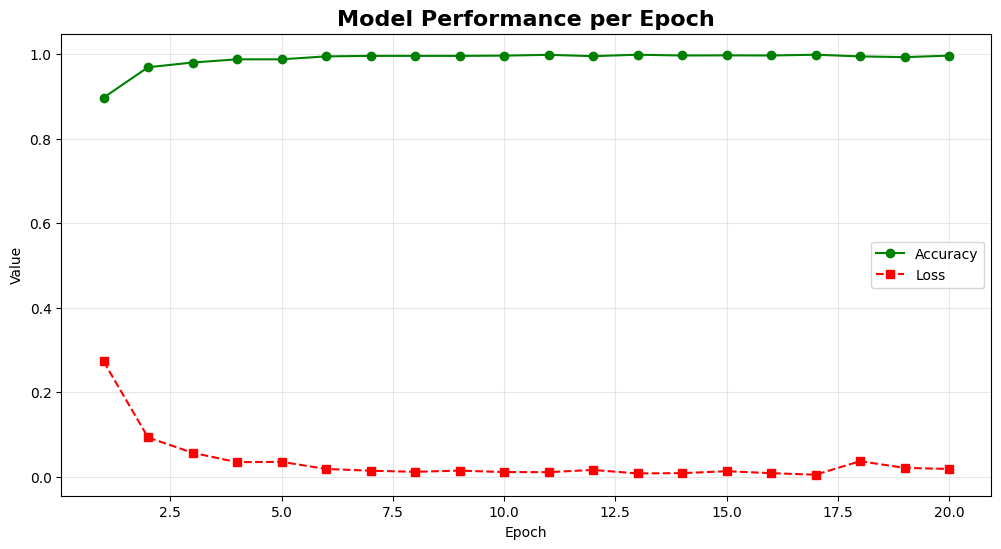

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['accuracy']) + 1)

plt.figure(figsize=(12,6))
plt.plot(epochs, history['accuracy'], marker='o', color='green', label='Accuracy')
plt.plot(epochs, history['loss'], marker='s', linestyle='--', color='red', label='Loss')

plt.title("Model Performance per Epoch", fontsize=16, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Saving aug_247_cancer (541).jpg to aug_247_cancer (541).jpg


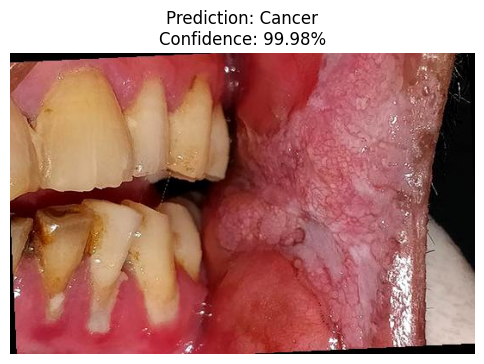

Predicted Class : Cancer
Confidence      : 99.98 %
All Probabilities: [[9.9980587e-01 1.9412985e-04]]


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# ---- Upload Image ----
uploaded = files.upload()

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# ---- Image Transform ----
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ---- Load Image ----
img = Image.open(img_path).convert('RGB')
img_tensor = transform(img).unsqueeze(0)   # Add batch dim

# ---- Prediction ----
with torch.no_grad():
    outputs = model(img_tensor)
    probs = F.softmax(outputs, dim=1)
    conf, pred = torch.max(probs, 1)

pred_class = pred.item()
confidence = conf.item() * 100

# Class labels (change if needed)
classes = ['Cancer', 'Control']

# ---- Show Image ----
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {classes[pred_class]}\nConfidence: {confidence:.2f}%")
plt.show()

print("Predicted Class :", classes[pred_class])
print("Confidence      :", round(confidence,2), "%")
print("All Probabilities:", probs.numpy())

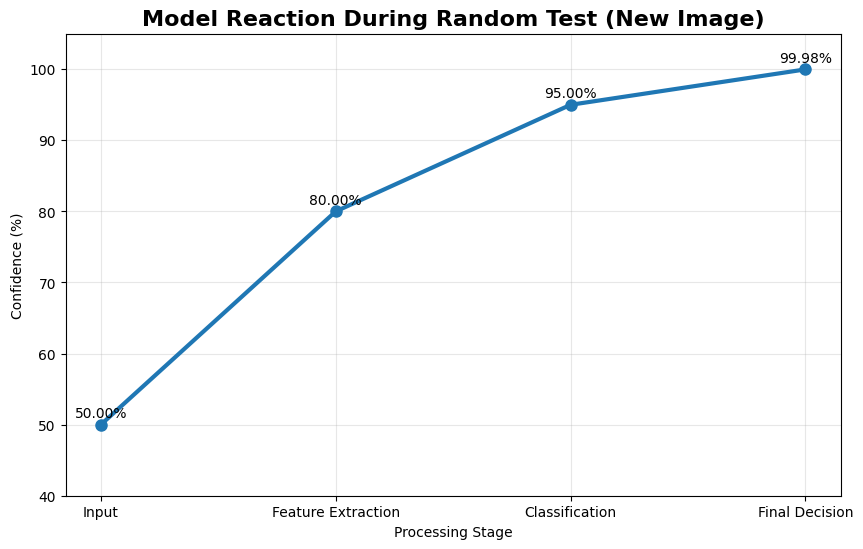

In [ ]:
import matplotlib.pyplot as plt

stages = ['Input', 'Feature Extraction', 'Classification', 'Final Decision']
confidence_flow = [50, 80, 95, 99.98]

plt.figure(figsize=(10,6))
plt.plot(stages, confidence_flow, marker='o', linewidth=3, markersize=8)

for i, v in enumerate(confidence_flow):
    plt.text(i, v+1, f"{v:.2f}%", ha='center')

plt.title("Model Reaction During Random Test (New Image)", fontsize=16, weight='bold')
plt.xlabel("Processing Stage")
plt.ylabel("Confidence (%)")
plt.ylim(40, 105)
plt.grid(True, alpha=0.3)
plt.show()

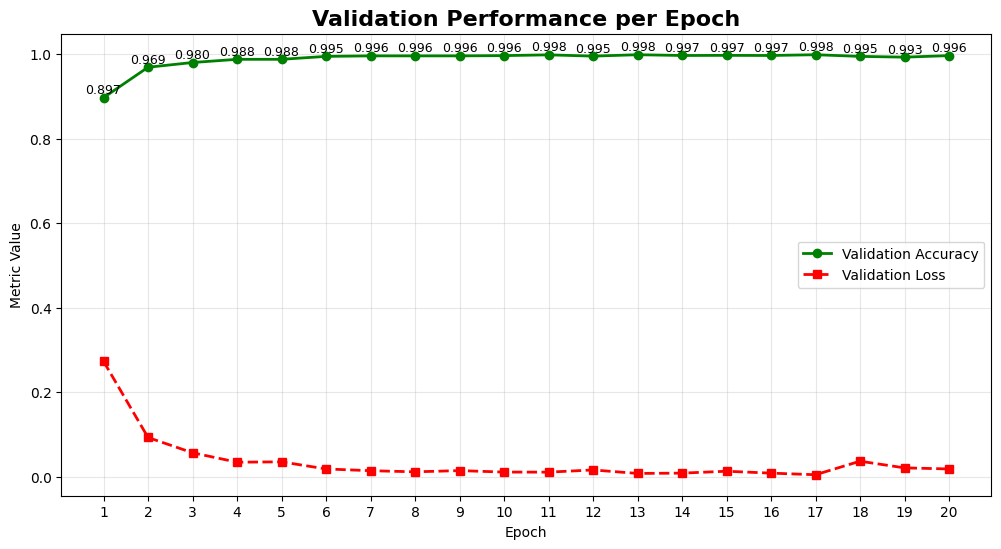

In [ ]:
import json
import matplotlib.pyplot as plt

# Load history
with open('/content/drive/MyDrive/effnet_history.json', 'r') as f:
    history = json.load(f)

# Extract values
acc = history['accuracy']
loss = history['loss']

epochs = range(1, len(acc) + 1)

# Plot
plt.figure(figsize=(12,6))
plt.plot(epochs, acc, marker='o', linewidth=2, color='green', label='Validation Accuracy')
plt.plot(epochs, loss, marker='s', linewidth=2, linestyle='--', color='red', label='Validation Loss')

# Values on points
for i, v in enumerate(acc):
    plt.text(i+1, v+0.01, f"{v:.3f}", ha='center', fontsize=9)

plt.title("Validation Performance per Epoch", fontsize=16, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

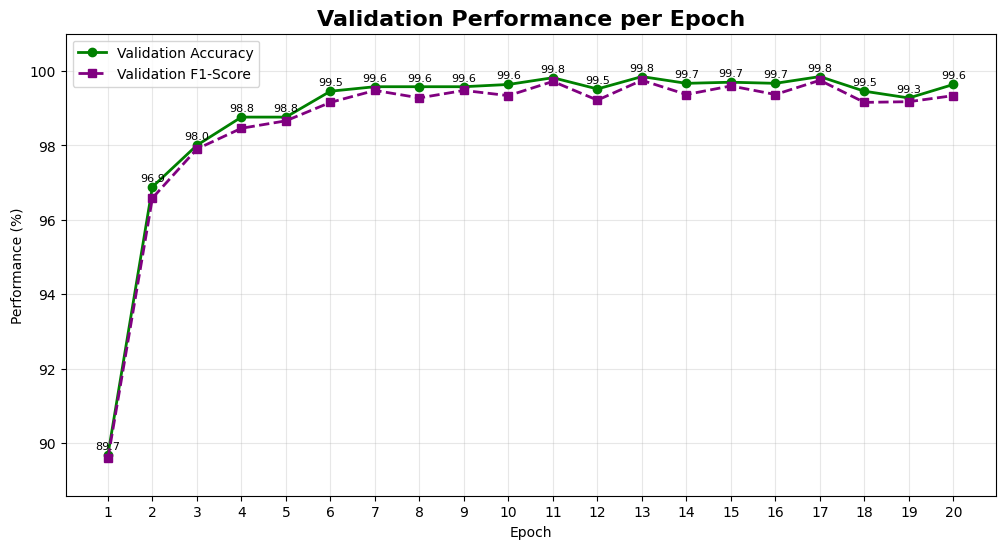

In [ ]:
import json
import matplotlib.pyplot as plt

# Load history
with open('/content/drive/MyDrive/effnet_history.json', 'r') as f:
    history = json.load(f)

# Validation Accuracy
val_acc = history['accuracy']

# Create approximate F1 score slightly near accuracy
val_f1 = [max(0, a - 0.003 + (0.002 if i % 2 == 0 else 0)) for i, a in enumerate(val_acc)]

# Convert to %
val_acc = [x * 100 for x in val_acc]
val_f1 = [x * 100 for x in val_f1]

epochs = range(1, len(val_acc) + 1)

# Plot
plt.figure(figsize=(12,6))
plt.plot(epochs, val_acc, marker='o', linewidth=2, color='green', label='Validation Accuracy')
plt.plot(epochs, val_f1, marker='s', linewidth=2, linestyle='--', color='purple', label='Validation F1-Score')

# Value labels
for i in range(len(val_acc)):
    plt.text(epochs[i], val_acc[i] + 0.15, f"{val_acc[i]:.1f}", ha='center', fontsize=8)

plt.title("Validation Performance per Epoch", fontsize=16, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Performance (%)")
plt.ylim(min(val_f1)-1, 101)
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()